In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def thomas_solve(a, b, c, d):
    n = len(b)
    for i in range(1, n):
        w = a[i-1]/b[i-1]
        b[i] = b[i] - w*c[i-1]
        d[i] = d[i] - w*d[i-1]
    x = np.zeros(n)
    x[-1] = d[-1]/b[-1]
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i]*x[i+1])/b[i]
    return x

## Question 1: Cooling a Hot Rod

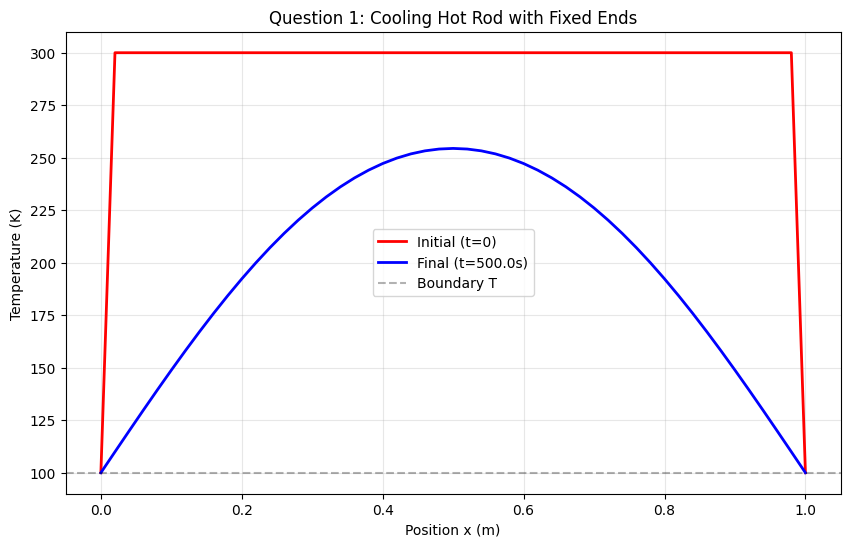

Initial center temperature: 300.00 K
Final center temperature: 254.43 K
Boundary temperature: 100.00 K

As t → ∞, the rod equilibrates to T0 = 100.00 K everywhere.


In [3]:
L = 1.0
Nx = 51
dx = L/(Nx-1)
alpha = 1e-4
dt = 0.1
Nt = 5000
r = alpha*dt/dx**2

x = np.linspace(0, L, Nx)
T0 = 100.0
Tinit = 300.0

T = np.full(Nx, Tinit)
T[0] = T0
T[-1] = T0

n_interior = Nx - 2
a_A = np.full(n_interior-1, -r/2)
b_A = np.full(n_interior, 1 + r)
c_A = np.full(n_interior-1, -r/2)

a_B = np.full(n_interior-1, r/2)
b_B = np.full(n_interior, 1 - r)
c_B = np.full(n_interior-1, r/2)

T_initial = T.copy()

for n in range(Nt):
    T_old = T.copy()
    T_in = T_old[1:-1]
    RHS = np.zeros(n_interior)
    
    for i in range(n_interior):
        RHS[i] = b_B[i]*T_in[i]
        if i > 0:
            RHS[i] += a_B[i-1]*T_in[i-1]
        if i < n_interior-1:
            RHS[i] += c_B[i]*T_in[i+1]
    
    RHS[0] += r * T0
    RHS[-1] += r * T0
    
    sol = thomas_solve(a_A.copy(), b_A.copy(), c_A.copy(), RHS.copy())
    T[1:-1] = sol
    T[0] = T0
    T[-1] = T0

plt.figure(figsize=(10, 6))
plt.plot(x, T_initial, 'r-', linewidth=2, label='Initial (t=0)')
plt.plot(x, T, 'b-', linewidth=2, label=f'Final (t={Nt*dt:.1f}s)')
plt.axhline(y=T0, color='k', linestyle='--', alpha=0.3, label='Boundary T')
plt.xlabel('Position x (m)')
plt.ylabel('Temperature (K)')
plt.title('Question 1: Cooling Hot Rod with Fixed Ends')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Initial center temperature: {T_initial[Nx//2]:.2f} K")
print(f"Final center temperature: {T[Nx//2]:.2f} K")
print(f"Boundary temperature: {T0:.2f} K")
print(f"\nAs t → ∞, the rod equilibrates to T0 = {T0:.2f} K everywhere.")

## Question 2: Different Boundary Temperatures

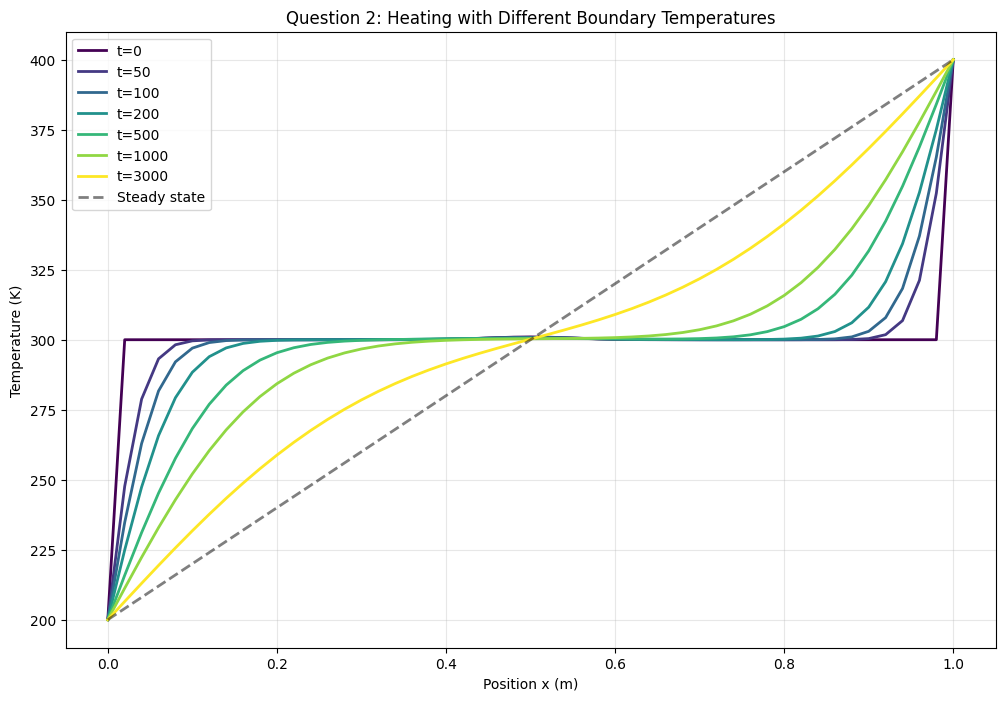

Left boundary: 200.0 K
Right boundary: 400.0 K

Steady state is linear: T(x) = 200.0 + 200.0*x
Final center temperature: 300.20 K
Steady-state center: 300.00 K
Difference: 0.2000 K


In [4]:
L = 1.0
Nx = 51
dx = L/(Nx-1)
alpha = 1e-4
dt = 0.1
r = alpha*dt/dx**2

x = np.linspace(0, L, Nx)
Tleft = 200.0
Tright = 400.0
sigma = 0.05

T = np.zeros(Nx)
for i in range(Nx):
    T[i] = 300.0 + np.exp(-(x[i] - L/2)**2 / (2*sigma**2))
T[0] = Tleft
T[-1] = Tright

n_interior = Nx - 2
a_A = np.full(n_interior-1, -r/2)
b_A = np.full(n_interior, 1 + r)
c_A = np.full(n_interior-1, -r/2)

a_B = np.full(n_interior-1, r/2)
b_B = np.full(n_interior, 1 - r)
c_B = np.full(n_interior-1, r/2)

snapshots = []
snapshot_times = [0, 50, 100, 200, 500, 1000, 3000]
snapshots.append(('t=0', T.copy()))

for n in range(max(snapshot_times)):
    T_old = T.copy()
    T_in = T_old[1:-1]
    RHS = np.zeros(n_interior)
    
    for i in range(n_interior):
        RHS[i] = b_B[i]*T_in[i]
        if i > 0:
            RHS[i] += a_B[i-1]*T_in[i-1]
        if i < n_interior-1:
            RHS[i] += c_B[i]*T_in[i+1]
    
    RHS[0] += r * Tleft
    RHS[-1] += r * Tright
    
    sol = thomas_solve(a_A.copy(), b_A.copy(), c_A.copy(), RHS.copy())
    T[1:-1] = sol
    T[0] = Tleft
    T[-1] = Tright
    
    if n+1 in snapshot_times:
        snapshots.append((f't={n+1}', T.copy()))

plt.figure(figsize=(12, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(snapshots)))
for (label, temp), color in zip(snapshots, colors):
    plt.plot(x, temp, linewidth=2, label=label, color=color)

steady_state = Tleft + (Tright - Tleft) * x / L
plt.plot(x, steady_state, 'k--', linewidth=2, alpha=0.5, label='Steady state')

plt.xlabel('Position x (m)')
plt.ylabel('Temperature (K)')
plt.title('Question 2: Heating with Different Boundary Temperatures')
plt.legend(loc='best')
plt.grid(alpha=0.3)
plt.show()

print(f"Left boundary: {Tleft:.1f} K")
print(f"Right boundary: {Tright:.1f} K")
print(f"\nSteady state is linear: T(x) = {Tleft:.1f} + {Tright-Tleft:.1f}*x")
print(f"Final center temperature: {T[Nx//2]:.2f} K")
print(f"Steady-state center: {steady_state[Nx//2]:.2f} K")
print(f"Difference: {abs(T[Nx//2] - steady_state[Nx//2]):.4f} K")

## Additional Analysis: Effect of Parameters

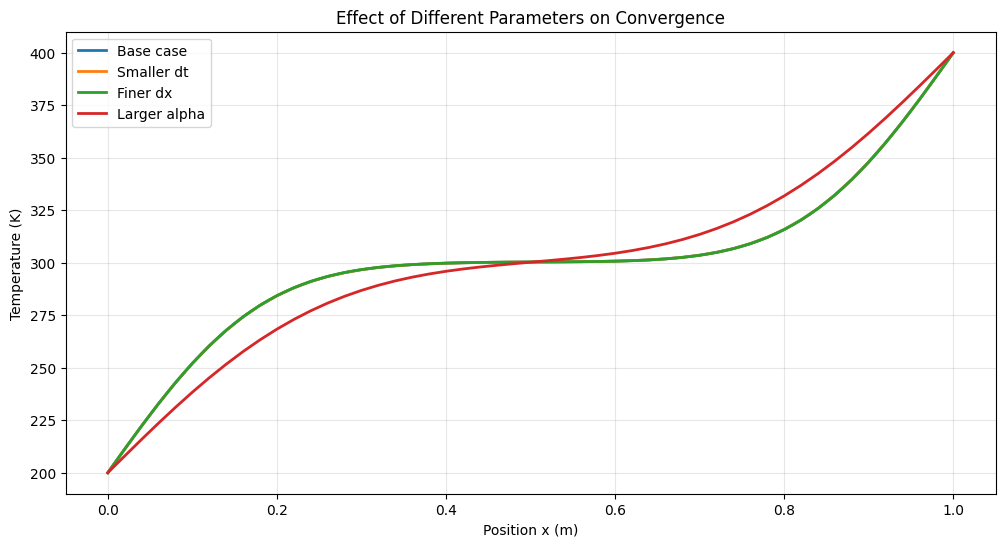

Parameter effects on convergence speed:
- Smaller dt: More time steps needed for same physical time
- Finer dx: Better spatial resolution, may need adjustment in dt
- Larger alpha: Faster heat diffusion, quicker convergence


In [5]:
def run_simulation(Nx_val, dt_val, alpha_val, Nt_val):
    L = 1.0
    dx = L/(Nx_val-1)
    r = alpha_val*dt_val/dx**2
    
    x = np.linspace(0, L, Nx_val)
    Tleft = 200.0
    Tright = 400.0
    sigma = 0.05
    
    T = np.zeros(Nx_val)
    for i in range(Nx_val):
        T[i] = 300.0 + np.exp(-(x[i] - L/2)**2 / (2*sigma**2))
    T[0] = Tleft
    T[-1] = Tright
    
    n_interior = Nx_val - 2
    a_A = np.full(n_interior-1, -r/2)
    b_A = np.full(n_interior, 1 + r)
    c_A = np.full(n_interior-1, -r/2)
    
    a_B = np.full(n_interior-1, r/2)
    b_B = np.full(n_interior, 1 - r)
    c_B = np.full(n_interior-1, r/2)
    
    for n in range(Nt_val):
        T_old = T.copy()
        T_in = T_old[1:-1]
        RHS = np.zeros(n_interior)
        
        for i in range(n_interior):
            RHS[i] = b_B[i]*T_in[i]
            if i > 0:
                RHS[i] += a_B[i-1]*T_in[i-1]
            if i < n_interior-1:
                RHS[i] += c_B[i]*T_in[i+1]
        
        RHS[0] += r * Tleft
        RHS[-1] += r * Tright
        
        sol = thomas_solve(a_A.copy(), b_A.copy(), c_A.copy(), RHS.copy())
        T[1:-1] = sol
        T[0] = Tleft
        T[-1] = Tright
    
    return x, T

configs = [
    (51, 0.1, 1e-4, 1000, 'Base case'),
    (51, 0.05, 1e-4, 2000, 'Smaller dt'),
    (101, 0.1, 1e-4, 1000, 'Finer dx'),
    (51, 0.1, 2e-4, 1000, 'Larger alpha')
]

plt.figure(figsize=(12, 6))
for Nx_v, dt_v, alpha_v, Nt_v, label in configs:
    x_v, T_v = run_simulation(Nx_v, dt_v, alpha_v, Nt_v)
    plt.plot(x_v, T_v, linewidth=2, label=label)

plt.xlabel('Position x (m)')
plt.ylabel('Temperature (K)')
plt.title('Effect of Different Parameters on Convergence')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Parameter effects on convergence speed:")
print("- Smaller dt: More time steps needed for same physical time")
print("- Finer dx: Better spatial resolution, may need adjustment in dt")
print("- Larger alpha: Faster heat diffusion, quicker convergence")